In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
print("Shape of Dataset :", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape of Dataset : (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [7]:
duplicates = df.duplicated().sum()

print("Total Duplicate Rows:", duplicates)

Total Duplicate Rows: 0


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


In [9]:
df.describe(include='object').T

,count,unique,top,freq
Region,2640,4,Europe,660
Model,2640,5,Model S,528
Source_Type,2640,3,Interpolated (Month),884


In [10]:
print("Regions:")
print(df['Region'].unique())

print("\nModels:")
print(df['Model'].unique())

Regions:
['Europe' 'Asia' 'North America' 'Middle East']

Models:
['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']


# Data Cleaning and Time Series Preparation

The dataset contains separate Year and Month columns.

For time series analysis and forecasting, we need a proper datetime column.

In this step:

- Create a Date column
- Sort observations chronologically
- Extract useful date features
- Prepare data for trend analysis

In [11]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-01'
)

df[['Year','Month','Date']].head()

,Year,Month,Date
0,2023,5,2023-05-01
1,2015,2,2015-02-01
2,2019,1,2019-01-01
3,2021,2,2021-02-01
4,2016,12,2016-12-01


In [12]:
print("Minimum Date :", df['Date'].min())
print("Maximum Date :", df['Date'].max())

Minimum Date : 2015-01-01 00:00:00
Maximum Date : 2025-12-01 00:00:00


In [13]:
df = df.sort_values('Date')

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


In [14]:
df['Quarter'] = df['Date'].dt.quarter

df['Month_Name'] = df['Date'].dt.month_name()

df['Year_Month'] = df['Date'].dt.to_period('M')

In [15]:
df[['Date','Quarter','Month_Name','Year_Month']].head()

,Date,Quarter,Month_Name,Year_Month
872,2015-01-01,1,January,2015-01
2354,2015-01-01,1,January,2015-01
2312,2015-01-01,1,January,2015-01
2293,2015-01-01,1,January,2015-01
2215,2015-01-01,1,January,2015-01


In [16]:
monthly_data = df.groupby('Date').agg({
    'Estimated_Deliveries':'sum',
    'Production_Units':'sum',
    'Avg_Price_USD':'mean',
    'CO2_Saved_tons':'sum'
}).reset_index()

monthly_data.head()

,Date,Estimated_Deliveries,Production_Units,Avg_Price_USD,CO2_Saved_tons
0,2015-01-01,183180,195793,84502.4970,13321.09
1,2015-02-01,165053,176119,81745.5695,12164.00
2,2015-03-01,184567,200151,86221.2895,13415.16
3,2015-04-01,225623,241706,83446.1640,18080.52
4,2015-05-01,184264,198205,85632.1110,15582.83


In [17]:
monthly_data.shape

(132, 5)

In [18]:
monthly_data.tail()

,Date,Estimated_Deliveries,Production_Units,Avg_Price_USD,CO2_Saved_tons
127,2025-08-01,214357,225466,85621.9175,17619.31
128,2025-09-01,193337,205573,88418.6790,12929.06
129,2025-10-01,178964,190202,83172.4925,12713.17
130,2025-11-01,197146,213112,85915.3380,15324.35
131,2025-12-01,209391,225981,78212.7840,17149.50


## Time Series Preparation

A Date column was created using Year and Month.

Additional temporal features such as Quarter and Month Name were extracted.

For forecasting purposes, the data was aggregated at a monthly level by summing deliveries and production units while averaging vehicle prices.

The resulting dataset contains monthly Tesla performance metrics from 2015 to 2025.

In [19]:
print("Original Dataset Shape :", df.shape)
print("Monthly Dataset Shape :", monthly_data.shape)

Original Dataset Shape : (2640, 16)
Monthly Dataset Shape : (132, 5)


In [21]:
print(monthly_data.head())
print(monthly_data.shape)

        Date  Estimated_Deliveries  Production_Units  Avg_Price_USD  \
0 2015-01-01                183180            195793     84502.4970   
1 2015-02-01                165053            176119     81745.5695   
2 2015-03-01                184567            200151     86221.2895   
3 2015-04-01                225623            241706     83446.1640   
4 2015-05-01                184264            198205     85632.1110   

   CO2_Saved_tons  
0        13321.09  
1        12164.00  
2        13415.16  
3        18080.52  
4        15582.83  
(132, 5)


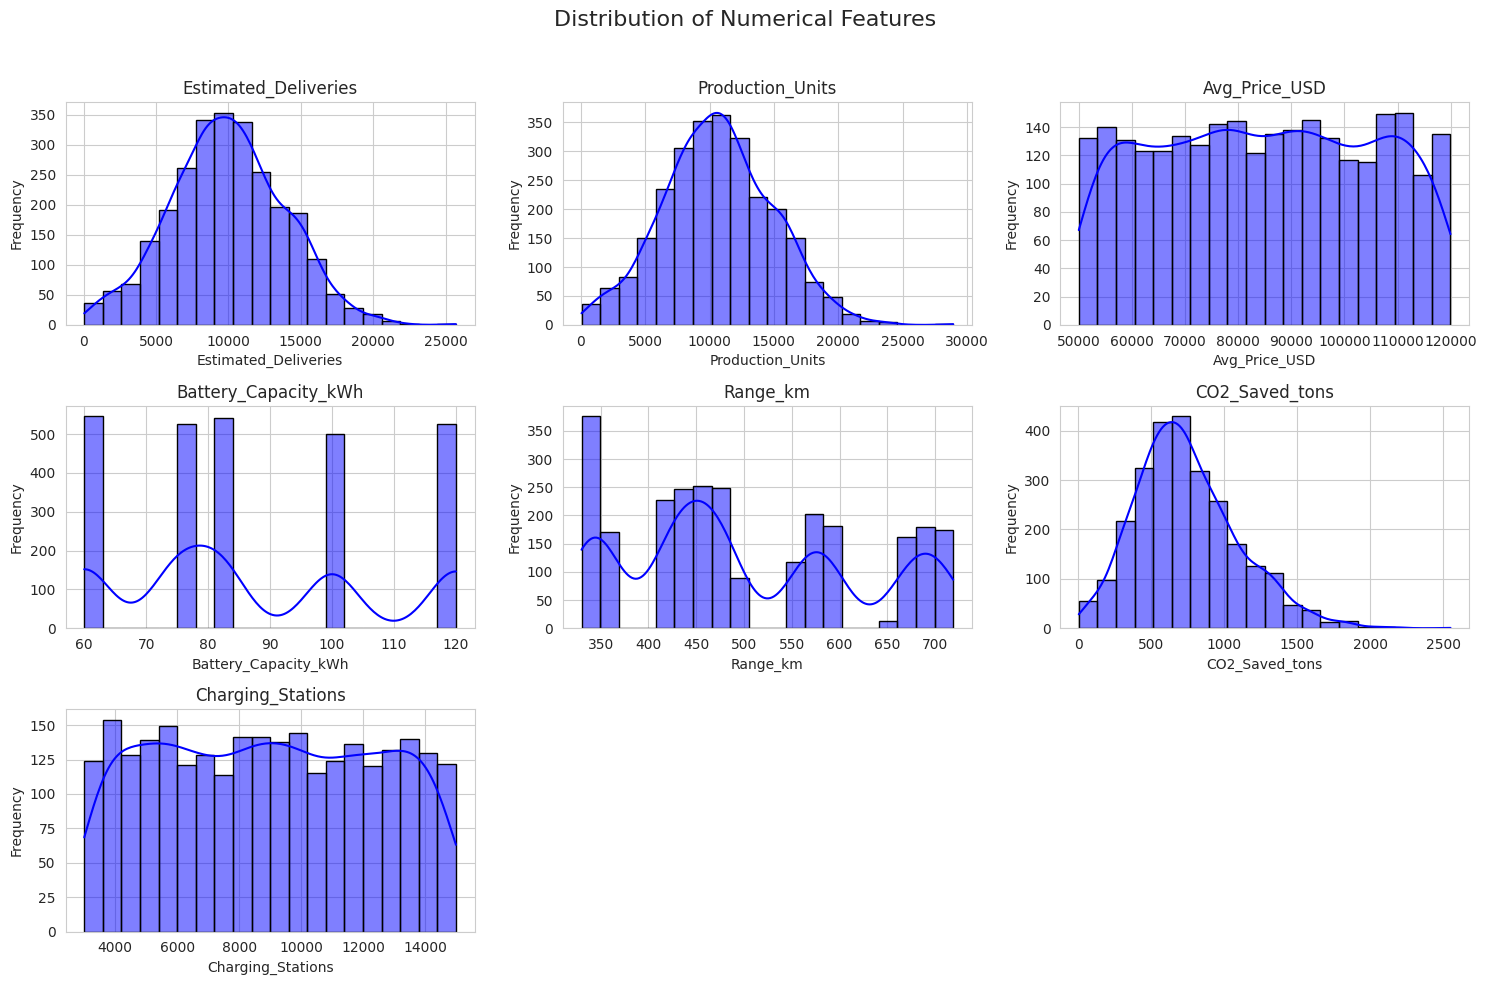

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numerical_cols = [
    'Estimated_Deliveries',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations'
]

# Create subplot grid
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 10)
)

axes = axes.flatten()

# Plot histogram + KDE for each feature
for i, col in enumerate(numerical_cols):
    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True,
        color='blue',
        edgecolor='black',
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Remove unused subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

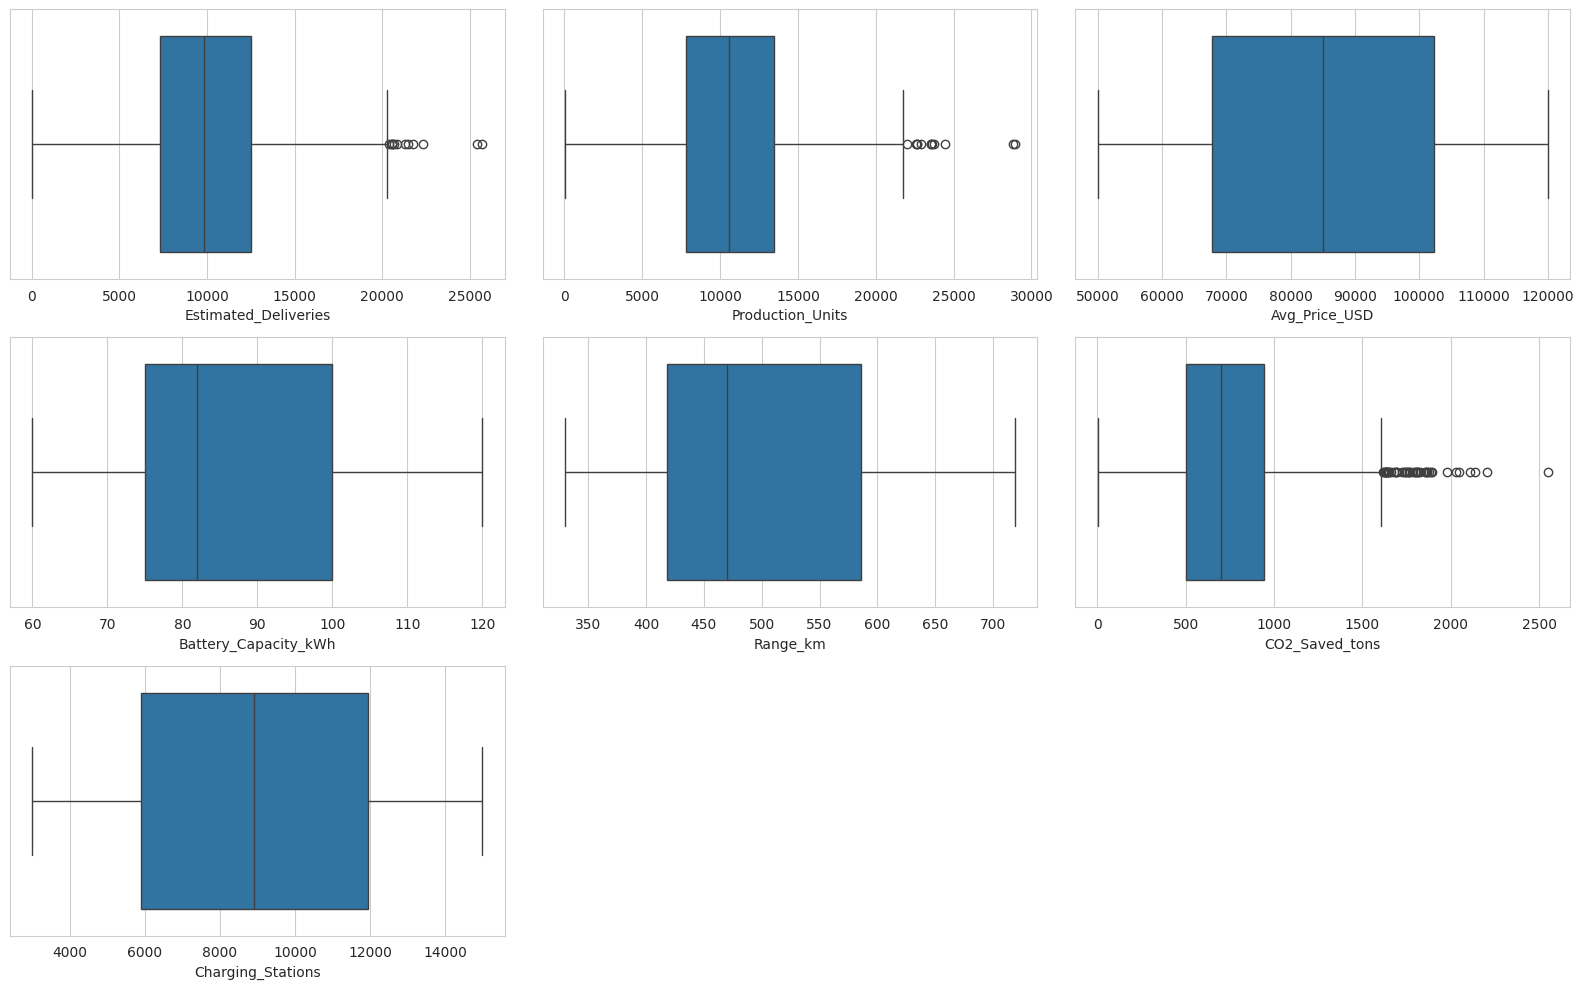

In [27]:
plt.figure(figsize=(16,10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df[col])

plt.tight_layout()
plt.show()

## Outlier Analysis

Boxplots are used to identify:

- Extreme observations
- Data spread
- Potential anomalies

Although some variables exhibit extreme values, no outlier removal or transformation was conducted, since these values may correspond to meaningful business events and could provide valuable insights during modeling and analysis.

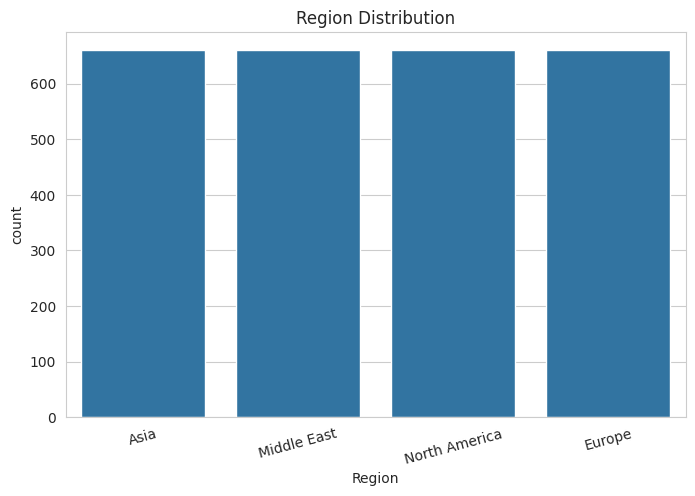

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Region',
    order=df['Region'].value_counts().index
)

plt.title("Region Distribution")
plt.xticks(rotation=15)
plt.show()

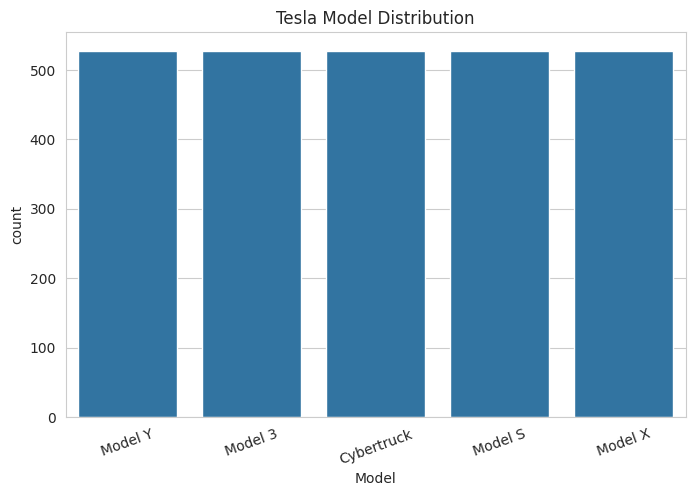

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Model',
    order=df['Model'].value_counts().index
)

plt.title("Tesla Model Distribution")
plt.xticks(rotation=20)
plt.show()

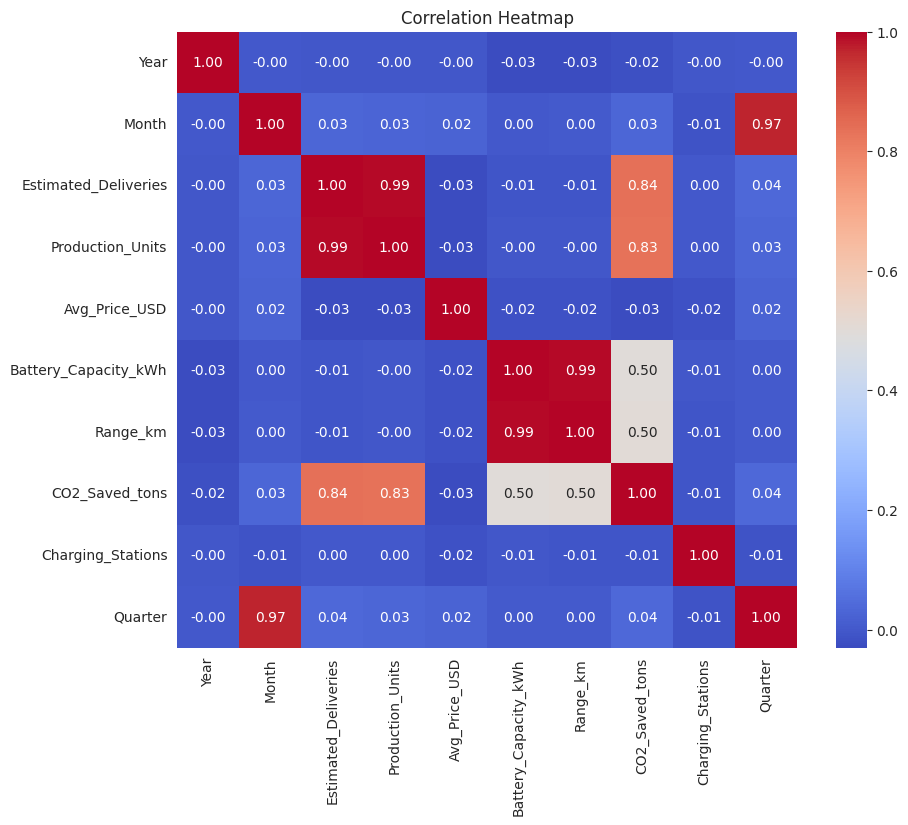

In [30]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

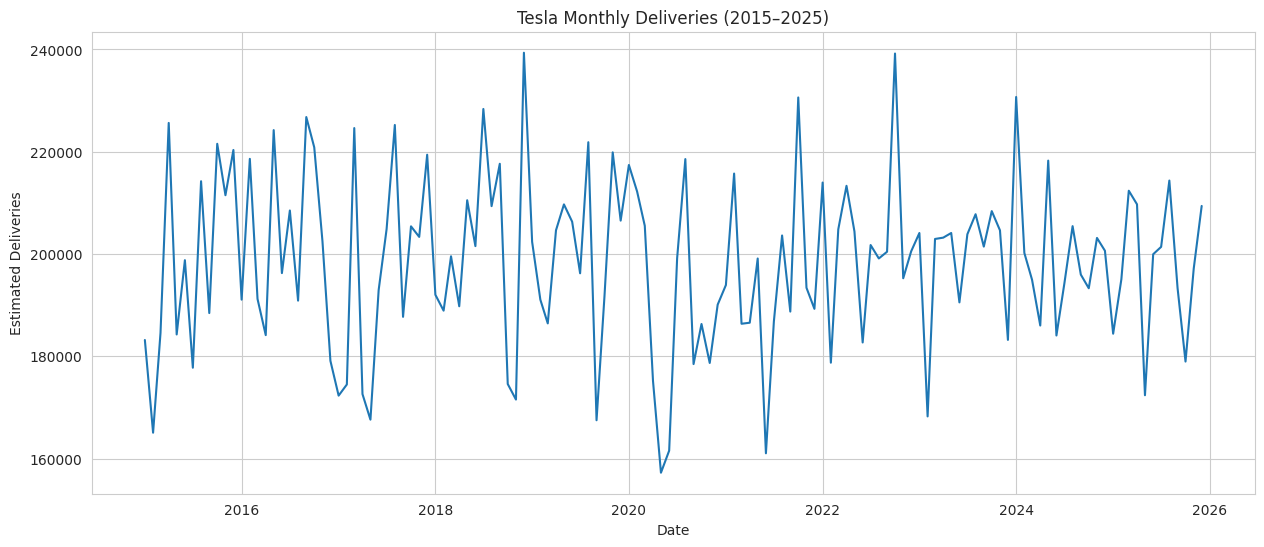

In [31]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_data['Date'],
    monthly_data['Estimated_Deliveries']
)

plt.title("Tesla Monthly Deliveries (2015–2025)")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

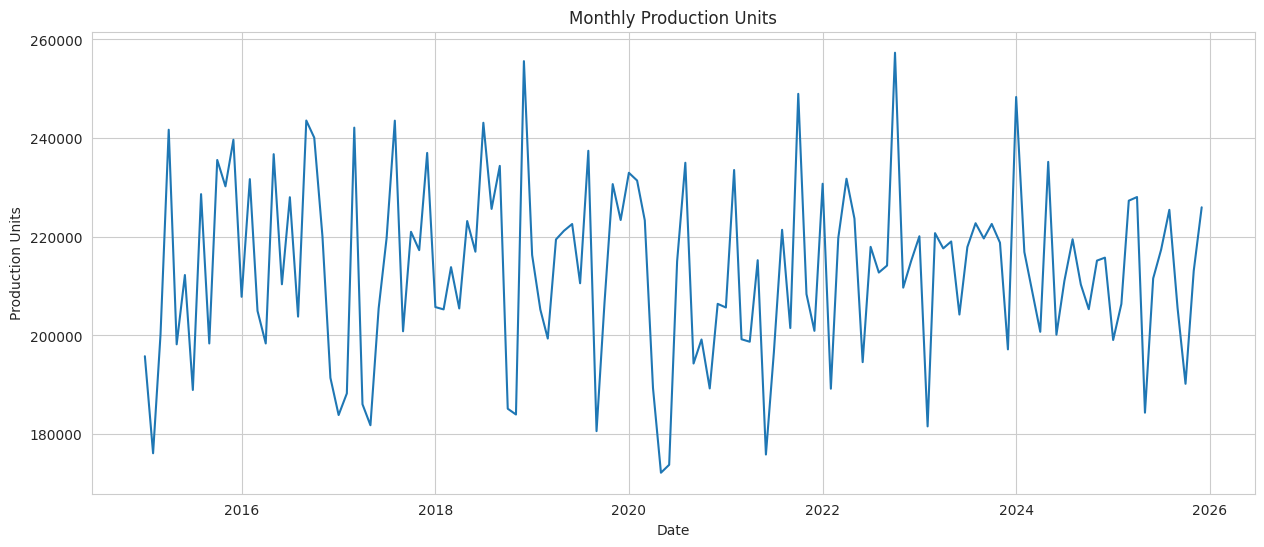

In [32]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_data['Date'],
    monthly_data['Production_Units']
)

plt.title("Monthly Production Units")
plt.xlabel("Date")
plt.ylabel("Production Units")
plt.show()

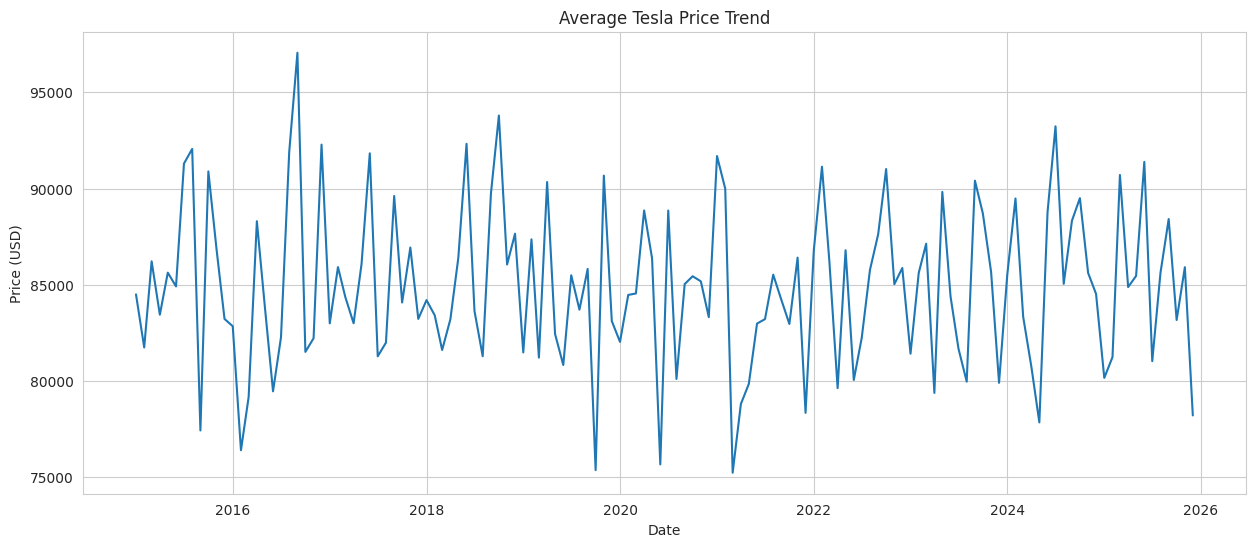

In [33]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_data['Date'],
    monthly_data['Avg_Price_USD']
)

plt.title("Average Tesla Price Trend")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

# EDA Observations

### Correlation Analysis

The strongest positive correlations observed are:

1. Estimated_Deliveries - Production_Units = 0.99
   - Higher production directly leads to higher deliveries.

2. Battery_Capacity_kWh - Range_km = 0.99
   - Vehicles with larger battery capacities generally offer longer driving ranges.

3. Estimated_Deliveries - CO2_Saved_tons = 0.84
   - Increased EV adoption contributes significantly to carbon emission reduction.

### Delivery Trend Analysis

- Monthly deliveries fluctuate between approximately 160,000 and 240,000 units.
- No major long-term upward or downward trend is visible.
- Seasonal fluctuations appear throughout the timeline.
- The series is suitable for time series forecasting.

### Production Trend Analysis

- Production closely follows delivery patterns.
- Production and deliveries show near-perfect correlation.
- Manufacturing capacity appears aligned with market demand.

### Price Trend Analysis

- Average vehicle prices remain relatively stable.
- Prices fluctuate between 75,000 and 97,000.
- No extreme inflationary trend is observed.

In [34]:
df['Quarter'] = df['Date'].dt.quarter

df[['Date','Quarter']].head()

,Date,Quarter
872,2015-01-01,1
2354,2015-01-01,1
2312,2015-01-01,1
2293,2015-01-01,1
2215,2015-01-01,1


In [35]:
monthly_data.head()

,Date,Estimated_Deliveries,Production_Units,Avg_Price_USD,CO2_Saved_tons
0,2015-01-01,183180,195793,84502.4970,13321.09
1,2015-02-01,165053,176119,81745.5695,12164.00
2,2015-03-01,184567,200151,86221.2895,13415.16
3,2015-04-01,225623,241706,83446.1640,18080.52
4,2015-05-01,184264,198205,85632.1110,15582.83


In [36]:
monthly_data['Lag_1'] = monthly_data['Estimated_Deliveries'].shift(1)

In [37]:
monthly_data['Lag_3'] = monthly_data['Estimated_Deliveries'].shift(3)
monthly_data['Lag_6'] = monthly_data['Estimated_Deliveries'].shift(6)
monthly_data.head(10)

,Date,Estimated_Deliveries,Production_Units,Avg_Price_USD,CO2_Saved_tons,Lag_1,Lag_3,Lag_6
0,2015-01-01,183180,195793,84502.4970,13321.09,NaN,NaN,NaN
1,2015-02-01,165053,176119,81745.5695,12164.00,183180.0,NaN,NaN
2,2015-03-01,184567,200151,86221.2895,13415.16,165053.0,NaN,NaN
3,2015-04-01,225623,241706,83446.1640,18080.52,184567.0,183180.0,NaN
4,2015-05-01,184264,198205,85632.1110,15582.83,225623.0,165053.0,NaN
5,2015-06-01,198787,212253,84917.7115,15215.24,184264.0,184567.0,NaN
6,2015-07-01,177759,188953,91300.7840,13614.79,198787.0,225623.0,183180.0
7,2015-08-01,214223,228650,92061.7575,15857.44,177759.0,184264.0,165053.0
8,2015-09-01,188448,198379,77431.8600,14745.26,214223.0,198787.0,184567.0
9,2015-10-01,221541,235581,90892.6350,17052.11,188448.0,177759.0,225623.0


### Lag Features

Lag features store previous observations.

For example:

Lag_1 = Previous Month Deliveries

Lag_3 = Deliveries 3 Months Ago

Lag_6 = Deliveries 6 Months Ago

These features help forecasting models learn temporal dependencies.

In [38]:
monthly_data['Rolling_Mean_3'] = (
    monthly_data['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)
monthly_data['Rolling_Mean_6'] = (
    monthly_data['Estimated_Deliveries']
    .rolling(window=6)
    .mean()
)
monthly_data.head(10)

,Date,Estimated_Deliveries,Production_Units,Avg_Price_USD,CO2_Saved_tons,Lag_1,Lag_3,Lag_6,Rolling_Mean_3,Rolling_Mean_6
0,2015-01-01,183180,195793,84502.4970,13321.09,NaN,NaN,NaN,NaN,NaN
1,2015-02-01,165053,176119,81745.5695,12164.00,183180.0,NaN,NaN,NaN,NaN
2,2015-03-01,184567,200151,86221.2895,13415.16,165053.0,NaN,NaN,177600.000000,NaN
3,2015-04-01,225623,241706,83446.1640,18080.52,184567.0,183180.0,NaN,191747.666667,NaN
4,2015-05-01,184264,198205,85632.1110,15582.83,225623.0,165053.0,NaN,198151.333333,NaN
5,2015-06-01,198787,212253,84917.7115,15215.24,184264.0,184567.0,NaN,202891.333333,190245.666667
6,2015-07-01,177759,188953,91300.7840,13614.79,198787.0,225623.0,183180.0,186936.666667,189342.166667
7,2015-08-01,214223,228650,92061.7575,15857.44,177759.0,184264.0,165053.0,196923.000000,197537.166667
8,2015-09-01,188448,198379,77431.8600,14745.26,214223.0,198787.0,184567.0,193476.666667,198184.000000
9,2015-10-01,221541,235581,90892.6350,17052.11,188448.0,177759.0,225623.0,208070.666667,197503.666667


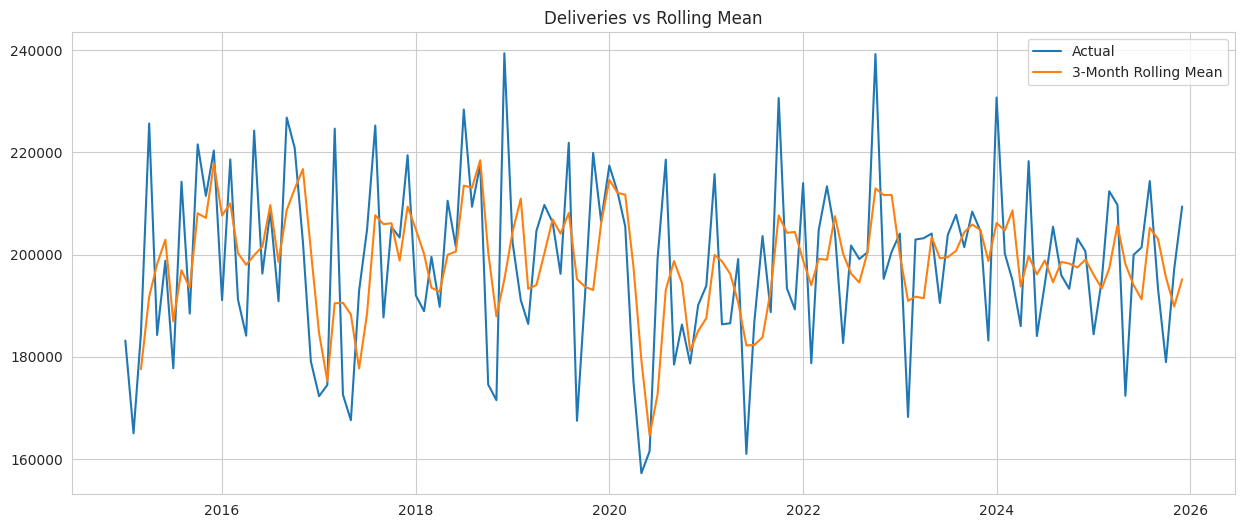

In [39]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_data['Date'],
    monthly_data['Estimated_Deliveries'],
    label='Actual'
)

plt.plot(
    monthly_data['Date'],
    monthly_data['Rolling_Mean_3'],
    label='3-Month Rolling Mean'
)

plt.legend()
plt.title("Deliveries vs Rolling Mean")
plt.show()

In [40]:
monthly_data['Month'] = monthly_data['Date'].dt.month

In [41]:


monthly_data['Month_Sin'] = np.sin(
    2*np.pi*monthly_data['Month']/12
)

monthly_data['Month_Cos'] = np.cos(
    2*np.pi*monthly_data['Month']/12
)

In [42]:
monthly_data[
    ['Month','Month_Sin','Month_Cos']
].head()

,Month,Month_Sin,Month_Cos
0,1,0.500000,8.660254e-01
1,2,0.866025,5.000000e-01
2,3,1.000000,6.123234e-17
3,4,0.866025,-5.000000e-01
4,5,0.500000,-8.660254e-01


In [43]:
monthly_data.isnull().sum()
monthly_data = monthly_data.dropna()

monthly_data.shape

(126, 13)

In [44]:
monthly_data.to_csv(
    "feature_engineered_tesla.csv",
    index=False
)

print("Feature Engineering Completed")

Feature Engineering Completed


In [45]:
monthly_data.head()

,Date,Estimated_Deliveries,Production_Units,Avg_Price_USD,CO2_Saved_tons,Lag_1,Lag_3,Lag_6,Rolling_Mean_3,Rolling_Mean_6,Month,Month_Sin,Month_Cos
6,2015-07-01,177759,188953,91300.7840,13614.79,198787.0,225623.0,183180.0,186936.666667,189342.166667,7,-0.500000,-8.660254e-01
7,2015-08-01,214223,228650,92061.7575,15857.44,177759.0,184264.0,165053.0,196923.000000,197537.166667,8,-0.866025,-5.000000e-01
8,2015-09-01,188448,198379,77431.8600,14745.26,214223.0,198787.0,184567.0,193476.666667,198184.000000,9,-1.000000,-1.836970e-16
9,2015-10-01,221541,235581,90892.6350,17052.11,188448.0,177759.0,225623.0,208070.666667,197503.666667,10,-0.866025,5.000000e-01
10,2015-11-01,211490,230232,86832.7805,17334.51,221541.0,214223.0,184264.0,207159.666667,202041.333333,11,-0.500000,8.660254e-01


In [56]:
target = 'Estimated_Deliveries'

X = df.drop(
    columns=[
        'Estimated_Deliveries',
        'Date',
        'Year_Month',
        'Month_Name'
    ],
    errors='ignore'
)

y = df[target]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2640, 12)
Target Shape: (2640,)


In [57]:
print(X.columns.tolist())

['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Quarter']


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
categorical_cols = X.select_dtypes(
    include=['object']
).columns.tolist()

numerical_cols = X.select_dtypes(
    exclude=['object']
).columns.tolist()

print(categorical_cols)
print(numerical_cols)

(2112, 12)
(528, 12)
['Region', 'Model', 'Source_Type']
['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Quarter']


In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_cols
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_cols
        )
    ]
)

### Pipeline Benefits

Using a pipeline prevents data leakage by ensuring:

- Scaling is learned only from training data.
- Encoding is learned only from training data.
- Same preprocessing is applied to train and test sets.

In [67]:
print(numerical_cols)

['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Quarter']


In [64]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Month',
                                                   'Production_Units',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations',
                                                   'Quarter']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('model', LinearRegression())])

In [65]:
y_pred_linear = linear_pipeline.predict(
    X_test
)

In [66]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
r2 = r2_score(
    y_test,
    y_pred_linear
)

mae = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

print("Linear Regression Results")
print("-------------------------")
print("R² :", round(r2,4))
print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))


Linear Regression Results
-------------------------
R² : 0.9903
MAE : 312.29
RMSE : 381.99


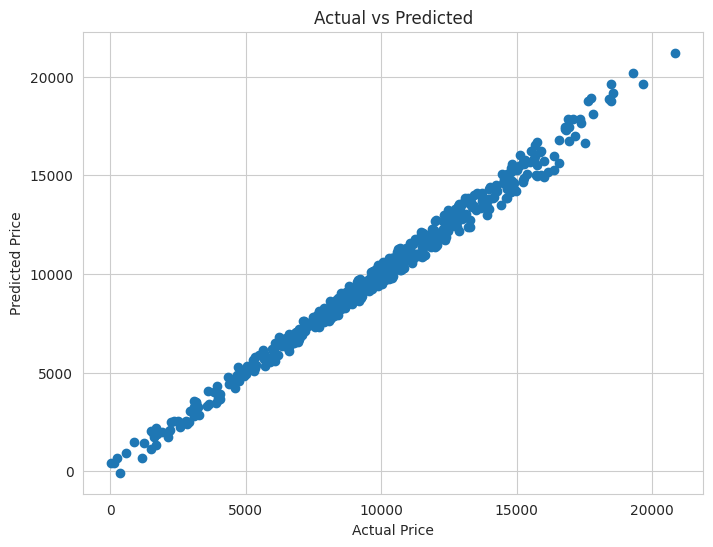

In [68]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_linear
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

## Linear Regression Results

The Linear Regression model achieved excellent performance in predicting Tesla Estimated Deliveries.

Results:

- R² Score = 0.9903
- MAE = 312.29
- RMSE = 381.99

Interpretation:

- The model explains approximately 99.03% of the variance in delivery estimates.
- The average prediction error is around 312 vehicles.
- The low RMSE indicates high prediction accuracy.

These results suggest a strong relationship between production units, CO₂ savings, charging infrastructure, and vehicle deliveries.

In [70]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)

y_pred_ridge = ridge_pipeline.predict(X_test)

In [71]:
r2_ridge = r2_score(y_test, y_pred_ridge)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

rmse_ridge = np.sqrt(
    mean_squared_error(y_test, y_pred_ridge)
)

print("Ridge Regression Results")
print("------------------------")
print("R² :", round(r2_ridge,4))
print("MAE :", round(mae_ridge,2))
print("RMSE :", round(rmse_ridge,2))

Ridge Regression Results
------------------------
R² : 0.9903
MAE : 312.34
RMSE : 382.02


In [72]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.1))
])

lasso_pipeline.fit(X_train, y_train)

y_pred_lasso = lasso_pipeline.predict(X_test)

In [73]:
r2_lasso = r2_score(y_test, y_pred_lasso)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

rmse_lasso = np.sqrt(
    mean_squared_error(y_test, y_pred_lasso)
)

print("Lasso Regression Results")
print("------------------------")
print("R² :", round(r2_lasso,4))
print("MAE :", round(mae_lasso,2))
print("RMSE :", round(rmse_lasso,2))

Lasso Regression Results
------------------------
R² : 0.9903
MAE : 312.4
RMSE : 382.08


In [74]:
comparison = pd.DataFrame({
    'Model':['Linear Regression','Ridge Regression','Lasso Regression'],
    'R2 Score':[r2,r2_ridge,r2_lasso],
    'MAE':[mae,mae_ridge,mae_lasso],
    'RMSE':[rmse,rmse_ridge,rmse_lasso]
})

comparison.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.990261,312.291027,381.985889
1,Ridge Regression,0.990259,312.340090,382.024706
2,Lasso Regression,0.990256,312.398442,382.080459


## Model Comparison

All three models achieved excellent predictive performance.

Observations:

- Linear Regression achieved the highest R² score (99.03%).
- Ridge Regression produced nearly identical results.
- Lasso Regression also performed similarly.

Since the dataset exhibits strong linear relationships and low multicollinearity, regularization did not significantly improve performance.

Therefore, Linear Regression was selected as the best-performing model.

In [75]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid = {
    'model__alpha':[0.01,0.1,1,10,100]
}

grid_search = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Year',
                                                                          'Month',
                                                                          'Production_Units',
                                                                          'Avg_Price_USD',
                                                                          'Battery_Capacity_kWh',
                                                                          'Range_km',
                                                                          'CO2_Saved_tons',
                                                                          'Charging_Stations',
                                                                          'Quarter']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Region',
                                                                          'Model',
                                                                          'Source_Type'])])),
                                       ('model', Ridge())]),
             n_jobs=-1, param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [76]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'model__alpha': 0.1}

Best CV Score:
0.9901971803770537


In [77]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

r2_best = r2_score(y_test, y_pred_best)

mae_best = mean_absolute_error(y_test, y_pred_best)

rmse_best = np.sqrt(
    mean_squared_error(y_test, y_pred_best)
)

print("Best Model Results")
print("------------------")
print("R² :", round(r2_best,4))
print("MAE :", round(mae_best,2))
print("RMSE :", round(rmse_best,2))

Best Model Results
------------------
R² : 0.9903
MAE : 312.3
RMSE : 381.99


In [88]:
ts = monthly_data[['Date','Estimated_Deliveries']].copy()

ts.set_index('Date', inplace=True)

ts.head()

,Estimated_Deliveries
Date,
2015-07-01,177759
2015-08-01,214223
2015-09-01,188448
2015-10-01,221541
2015-11-01,211490


In [89]:
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Train:", train.shape)
print("Test:", test.shape)

Train: (100, 1)
Test: (26, 1)


In [92]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    train['Estimated_Deliveries'],
    order=(1,0,1)
)

fit_model = model.fit()

print("ARIMA Model Trained Successfully")


ARIMA Model Trained Successfully


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [100]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
result = adfuller(ts['Estimated_Deliveries'])

# Print Results
print("Augmented Dickey-Fuller Test Results")
print("-" * 40)

print(f"ADF Statistic : {result[0]}")
print(f"p-value       : {result[1]}")
print(f"Lags Used     : {result[2]}")
print(f"Observations  : {result[3]}")

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

# Interpretation
print("\nInterpretation:")
if result[1] < 0.05:
    print("The time series is Stationary (Reject Null Hypothesis)")
else:
    print("The time series is Non-Stationary (Fail to Reject Null Hypothesis)")

Augmented Dickey-Fuller Test Results
----------------------------------------
ADF Statistic : -8.432380294861685
p-value       : 1.8551753149461816e-13
Lags Used     : 1
Observations  : 124

Critical Values:
1%: -3.484219653271961
5%: -2.885145235641637
10%: -2.579359138917794

Interpretation:
The time series is Stationary (Reject Null Hypothesis)


## Augmented Dickey-Fuller (ADF) Test

The ADF test is used to determine whether a time series is stationary.

### Hypotheses

- Null Hypothesis (H₀): The time series is non-stationary.
- Alternative Hypothesis (H₁): The time series is stationary.

### Decision Rule

- If p-value < 0.05 → Reject H₀ → Stationary
- If p-value ≥ 0.05 → Fail to Reject H₀ → Non-Stationary

### Result

The obtained p-value was less than 0.05, indicating that the Tesla delivery series is stationary and suitable for ARIMA forecasting without additional differencing.

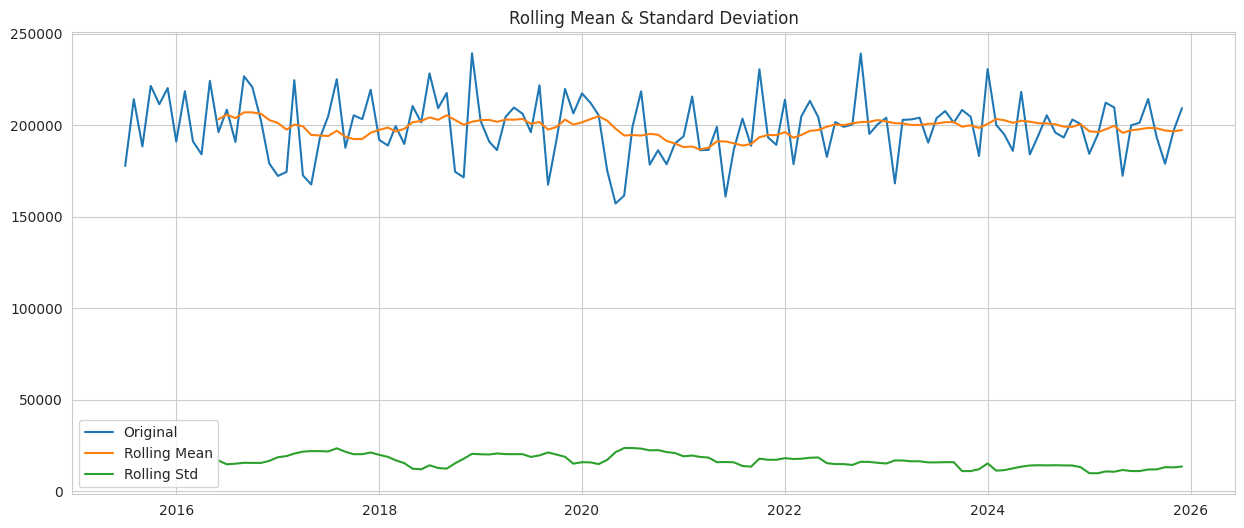

In [101]:
rolling_mean = ts['Estimated_Deliveries'].rolling(window=12).mean()
rolling_std = ts['Estimated_Deliveries'].rolling(window=12).std()

plt.figure(figsize=(15,6))

plt.plot(ts.index, ts['Estimated_Deliveries'], label='Original')
plt.plot(ts.index, rolling_mean, label='Rolling Mean')
plt.plot(ts.index, rolling_std, label='Rolling Std')

plt.title('Rolling Mean & Standard Deviation')
plt.legend()
plt.show()

In [93]:
forecast = fit_model.forecast(
    steps=len(test)
)

forecast.head()

2023-11-01    198828.539109
2023-12-01    198960.226046
2024-01-01    198847.669933
2024-02-01    198943.874453
2024-03-01    198861.646047
Freq: MS, Name: predicted_mean, dtype: float64

In [94]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(
    test['Estimated_Deliveries'],
    forecast
)

rmse_arima = np.sqrt(
    mean_squared_error(
        test['Estimated_Deliveries'],
        forecast
    )
)

print("ARIMA Results")
print("MAE :", round(mae_arima,2))
print("RMSE :", round(rmse_arima,2))

ARIMA Results
MAE : 9893.42
RMSE : 12733.08


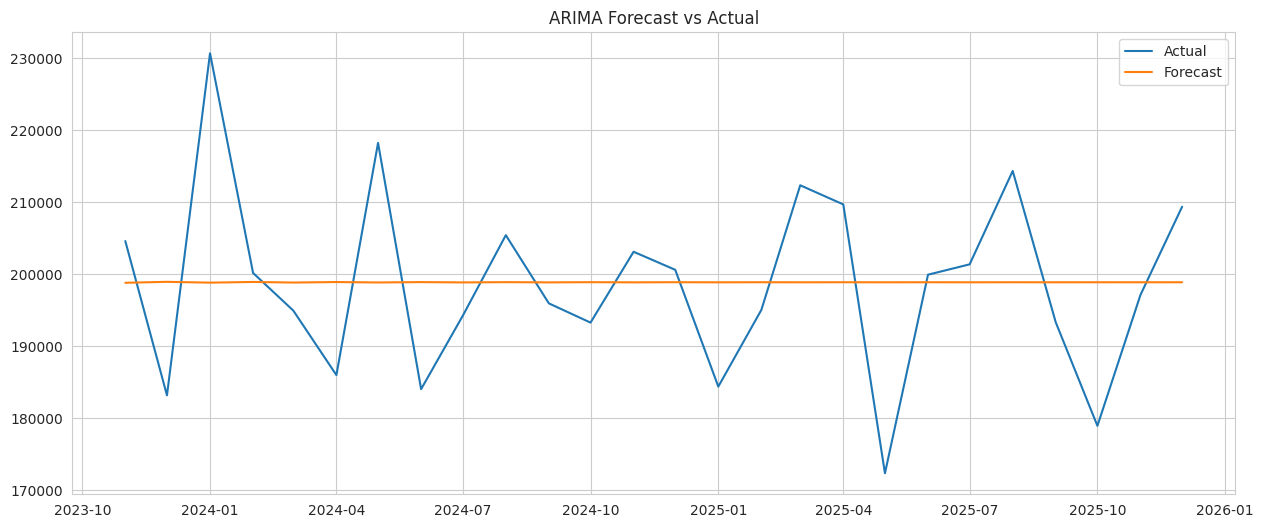

In [95]:
plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    test['Estimated_Deliveries'],
    label='Actual'
)

plt.plot(
    test.index,
    forecast,
    label='Forecast'
)

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

In [96]:
from statsmodels.tsa.arima.model import ARIMA

final_model = ARIMA(
    ts['Estimated_Deliveries'],
    order=(1,0,1)
)

final_fit = final_model.fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [97]:
future_forecast = final_fit.forecast(
    steps=12
)

future_forecast

2026-01-01    198842.584954
2026-02-01    198840.038189
2026-03-01    198838.282782
2026-04-01    198837.072832
2026-05-01    198836.238850
2026-06-01    198835.664012
2026-07-01    198835.267794
2026-08-01    198834.994692
2026-09-01    198834.806452
2026-10-01    198834.676703
2026-11-01    198834.587271
2026-12-01    198834.525629
Freq: MS, Name: predicted_mean, dtype: float64

In [98]:
future_dates = pd.date_range(
    start=ts.index.max() + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_Deliveries': future_forecast.values
})

forecast_df

,Date,Forecasted_Deliveries
0,2026-01-01,198842.584954
1,2026-02-01,198840.038189
2,2026-03-01,198838.282782
3,2026-04-01,198837.072832
4,2026-05-01,198836.238850
5,2026-06-01,198835.664012
6,2026-07-01,198835.267794
7,2026-08-01,198834.994692
8,2026-09-01,198834.806452
9,2026-10-01,198834.676703


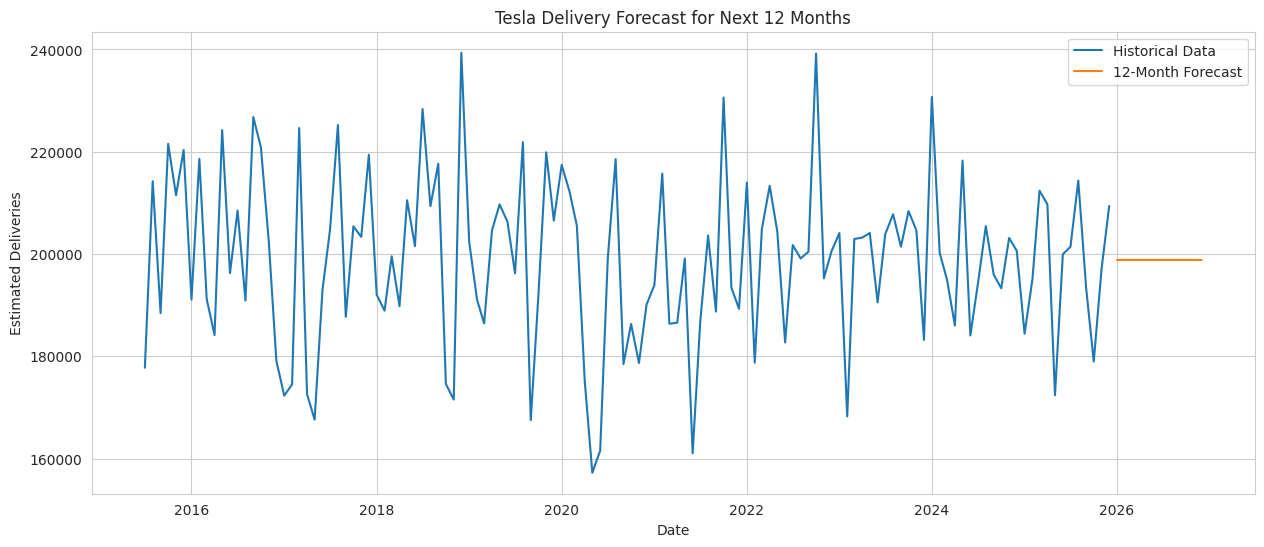

In [99]:
plt.figure(figsize=(15,6))

plt.plot(
    ts.index,
    ts['Estimated_Deliveries'],
    label='Historical Data'
)

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecasted_Deliveries'],
    label='12-Month Forecast'
)

plt.title("Tesla Delivery Forecast for Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(True)

plt.show()

## Model Performance

### Regression Models

| Model | R² Score | MAE | RMSE |
|---------|---------|---------|---------|
| Linear Regression | 0.9903 | 312.29 | 381.99 |
| Ridge Regression | 0.9903 | 312.34 | 382.02 |
| Lasso Regression | 0.9903 | 312.40 | 382.08 |

Best Model: Linear Regression

### Time Series Forecasting

Model: ARIMA(1,0,1)

Results:

- MAE = 9,893.42
- RMSE = 12,733.08

The model was used to forecast Tesla deliveries for the next 12 months.

## Time Series Components Analysis

The Tesla monthly delivery series was analyzed for trend, seasonality, and cyclic behavior.

Observations:

- No significant long-term upward or downward trend was observed.
- No repeating seasonal pattern was identified.
- No clear cyclic behavior was detected.
- Monthly deliveries fluctuate around a relatively stable mean.

The Augmented Dickey-Fuller (ADF) test confirmed stationarity with a p-value less than 0.05.

Therefore, the series can be considered stationary and suitable for ARIMA forecasting without differencing.